### 1. Install & import packages

In [57]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# ── Core data handling ──────────────────────────────────────
import pandas as pd
import numpy as np
from numpy.random import seed

# ── Preprocessing and pipelines ─────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,          # ← replaces KFold for classification
    GridSearchCV,
    cross_val_score
)
from sklearn.compose    import ColumnTransformer
from sklearn.pipeline   import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute     import SimpleImputer

# ── Tree-based classifiers ──────────────────────────────────
from sklearn.tree     import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

# ── Evaluation metrics ──────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)

# ── Imbalanced-learn ─────────────────────────────────────────
from imblearn.metrics import geometric_mean_score
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# ── Visualization ───────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load the dataset

In [58]:
df = pd.read_csv('data/Default.csv')

In [59]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


### 3. Explore & inspect the data

In [60]:
print("Dataset shape:", df.shape)
print(df.info())
print(df.describe())

Dataset shape: (10000, 4)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  str    
 1   student  10000 non-null  str    
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), str(2)
memory usage: 312.6 KB
None
            balance        income
count  10000.000000  10000.000000
mean     835.374886  33516.981876
std      483.714985  13336.639563
min        0.000000    771.967729
25%      481.731105  21340.462903
50%      823.636973  34552.644802
75%     1166.308386  43807.729272
max     2654.322576  73554.233495


### 4. Check & handle missing values

In [61]:
# Count the number of missing values per column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

Missing values per column:
default    0
student    0
balance    0
income     0
dtype: int64


In [62]:
# Calculate the proportion of missing values per column
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(f"\nMissing percentage: \n{missing_pct.astype(str) + ' %'}")


Missing percentage: 
default    0.0 %
student    0.0 %
balance    0.0 %
income     0.0 %
dtype: str


### 5. Encode the target variable

In [63]:
# Encode the 'default', No is 0 and Yes is 1
df['default'] = df['default'].map({'No': 0, 'Yes': 1})

In [64]:
print(df['default'].head())
print(df['default'].unique())
print(df['default'].dtype)

0    0
1    0
2    0
3    0
4    0
Name: default, dtype: int64
[0 1]
int64


### 6. Check class distribution

In [65]:
# Count of each class
print("Class counts:")
print(df['default'].value_counts())

# Convert to the percentage
print()
print("Class percentages:")
print(df['default'].value_counts(normalize=True).mul(100).round(2))

Class counts:
default
0    9667
1     333
Name: count, dtype: int64

Class percentages:
default
0    96.67
1     3.33
Name: proportion, dtype: float64


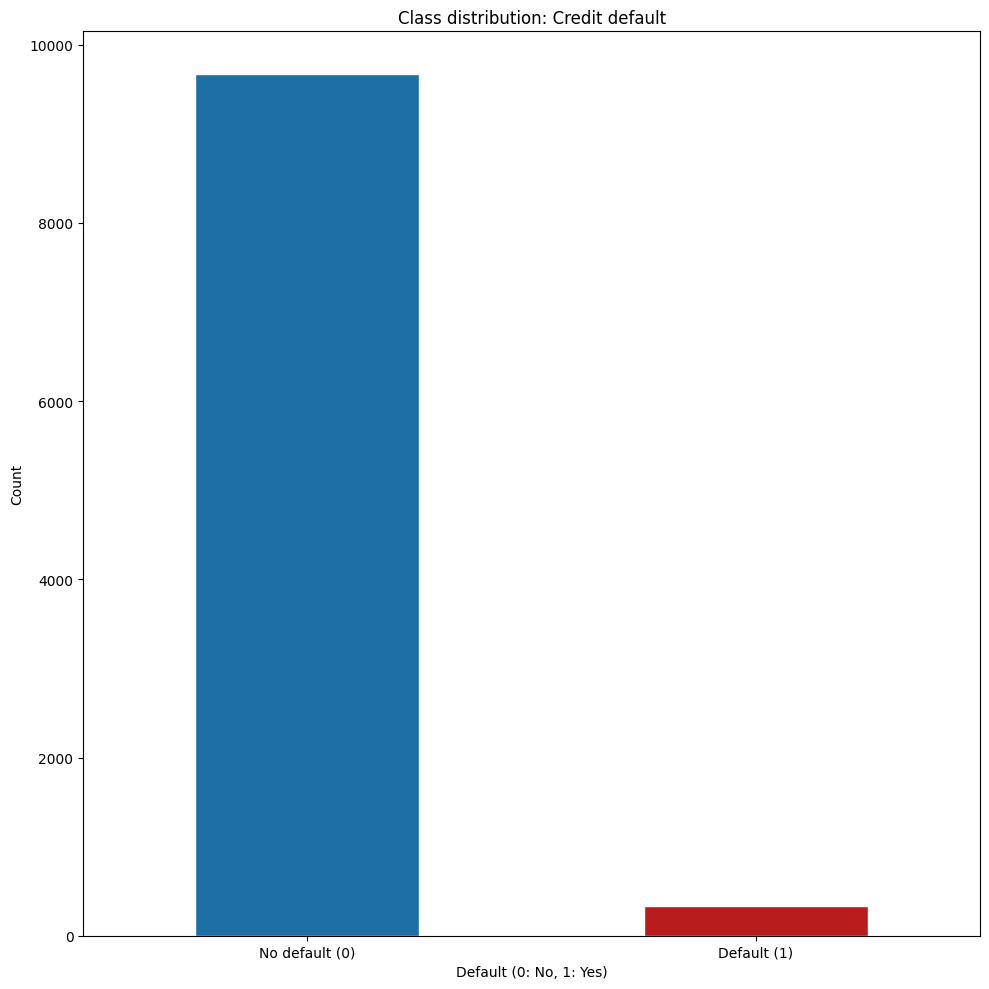

In [66]:
fig, ax = plt.subplots(figsize=(10, 10))
df['default'].value_counts().plot(
    kind='bar',
    ax=ax,
    color=['#1d6fa4', '#b91c1c'],
    edgecolor='white', 
    width=0.5
)

ax.set_title('Class distribution: Credit default', fontsize=12)
ax.set_xlabel('Default (0: No, 1: Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No default (0)', 'Default (1)'], rotation=0)
plt.tight_layout()
plt.show()

### 7.Pairwise scatter plot matrix

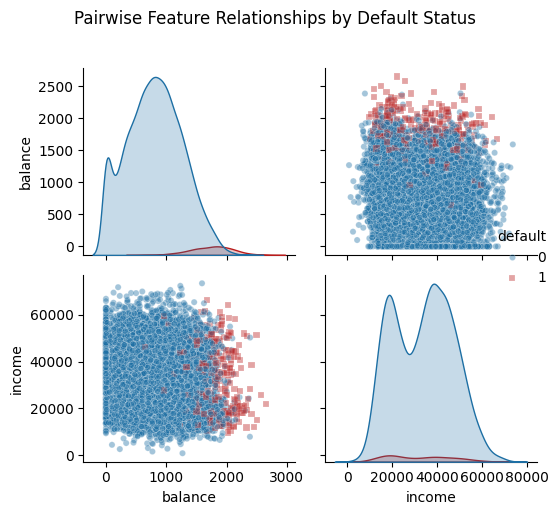

In [67]:
sns.pairplot(
    df,
    vars=['balance', 'income'],
    hue='default',
    palette={0: '#1d6fa4', 1: '#b91c1c'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20},
    markers=['o', 's']
)
plt.suptitle('Pairwise Feature Relationships by Default Status',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### 8. Correlation Heatmap

In [68]:
# Select numeric colmns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric features:", num_cols.tolist())

# Select categorical columns
cat_cols = df.select_dtypes(include=['str', 'object']).columns
print("Categorical features:", cat_cols.tolist())

Numeric features: ['default', 'balance', 'income']
Categorical features: ['student']


In [69]:
# Make a correlation matrix
cm = df[num_cols].corr()
print(cm)

          default   balance    income
default  1.000000  0.350119 -0.019871
balance  0.350119  1.000000 -0.152243
income  -0.019871 -0.152243  1.000000


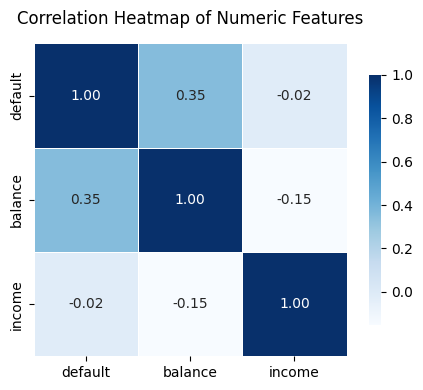

In [70]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=12, pad=14)
plt.tight_layout()
plt.show()

### 9. Train and test split 

In [71]:
# ── Separate features and target ──────────────────────────
X = df.drop('default', axis=1)
y = df['default']

# ── Train-test split ─────────────────────────────────────
#    REGRESSION used:  train_test_split(X, y, test_size=0.2, random_state=42)
#    CLASSIFICATION adds stratify=y ↓
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ← NEW: preserves class ratio in both splits
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"\nTrain default rate: {y_train.mean()*100:.2f}%")
print(f"Test  default rate: {y_test.mean()*100:.2f}%")

Training set  : 8000 samples
Test set      : 2000 samples

Train default rate: 3.33%
Test  default rate: 3.35%


### 10. Define the Feature lists

In [72]:
# ── Auto-detect types from training set ──────────────────
numeric_auto     = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_auto = X_train.select_dtypes(include=['object', 'bool', 'str']).columns

print("Numeric features:",     numeric_auto.tolist())
print("Categorical features:", categorical_auto.tolist())

# ── Explicitly define feature lists (recommended practice) ─
numeric_features     = ['balance', 'income']
categorical_features = ['student']

Numeric features: ['balance', 'income']
Categorical features: ['student']


### 11. Build the Preprocessing Pipeline

In [73]:
# ── Numeric pipeline: impute missing → standardize ────────
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # robust to outliers
    ('scaler',  StandardScaler())
])

# ── Categorical pipeline: impute missing → one-hot encode ─
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False))
])

# ── Combine into ColumnTransformer ────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,     numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

print("Preprocessor built successfully.")

Preprocessor built successfully.


### 12. Build the Modeling pipeline 


In [74]:
# ════ BEFORE (Regression Lab) ════════════════════════════
# pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('reg_SGD',      LinearRegressionGD())   ← REMOVE THIS
# ])

# ════ AFTER (Classification Lab) ════════════════════════
pipeline = Pipeline([
    ('preprocessor', preprocessor),     # ← identical, reused
    ('classifier',   DecisionTreeClassifier(  # ← swapped estimator
                         random_state=42))
])

print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['balance', 'income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                

### 13. Hyperparameter tuning with using Grid Seach 


In [75]:
# ── REGRESSION used: KFold(n_splits=5, shuffle=True, random_state=42)
# ── CLASSIFICATION uses StratifiedKFold ─────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# ── Multi-model param grid (list of dicts) ────────────────
# The key pattern: 'classifier__hyperparameter_name'
# mirrors your regression pattern: 'reg_SGD__eta', 'reg_SGD__n_iter'

param_grid = [

    # ─── 1. Decision Tree ────────────────────────────────
    {
        'classifier':             [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth':  [5, 10, 20, 30]
    },

    # ─── 2. Random Forest ────────────────────────────────
    {
        'classifier':                  [RandomForestClassifier(random_state=42)],
        'classifier__n_estimators':    [100, 200],
        'classifier__max_depth':       [3, 10, 20]
    },

    # ─── 3. Bagging with Decision Tree base ──────────────
    {
        'classifier': [BaggingClassifier(
                            estimator=DecisionTreeClassifier(),
                            random_state=42)],
        'classifier__n_estimators': [10, 50, 100]
    }

]
# ── GridSearchCV ─────────────────────────────────────────
grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'f1',        # ← was 'neg_mean_squared_error' in regression
    n_jobs     = -1,           # use all CPU cores
    verbose    = 1
)

# ── Fit on TRAINING data only ─────────────────────────────
grid_search.fit(X_train, y_train)

# ── Best results ─────────────────────────────────────────
print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 13 candidates, totalling 65 fits

Best parameters : {'classifier': RandomForestClassifier(random_state=42), 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
Best CV F1 score: 0.4402


### 14. Train the best Model 


In [76]:
# ── Extract best model ────────────────────────────────────
best_model = grid_search.best_estimator_

# ── Refit on full training data ───────────────────────────
best_model.fit(X_train, y_train)

# ── Generate predictions on train and test ────────────────
y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

print("Best estimator:")
print(grid_search.best_params_)

Best estimator:
{'classifier': RandomForestClassifier(random_state=42), 'classifier__max_depth': 3, 'classifier__n_estimators': 200}


### 15. Evaluate the best model 

=== FINAL MODEL PERFORMANCE ===
Train Accuracy  : 97.50%
Test  Accuracy  : 97.15%
Train Error Rate: 2.50%
Test  Error Rate: 2.85%
Train F1 Score  : 0.5000
Test  F1 Score  : 0.4466
Test  G-Mean    : 0.5839

Confusion Matrix (Test Set):
[[1920   13]
 [  44   23]]


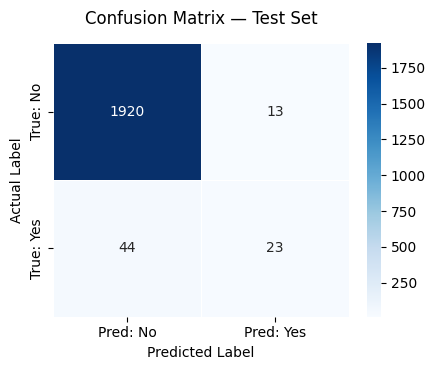

In [77]:
# ── Core metrics ─────────────────────────────────────────
acc_train  = accuracy_score(y_train, y_pred_train)
acc_test   = accuracy_score(y_test,  y_pred_test)
f1_train   = f1_score(y_train, y_pred_train)
f1_test    = f1_score(y_test,  y_pred_test)
gmean_test = geometric_mean_score(y_test, y_pred_test)

err_train  = 1 - acc_train
err_test   = 1 - acc_test

# ── Print summary ────────────────────────────────────────
print("=== FINAL MODEL PERFORMANCE ===")
print(f"Train Accuracy  : {acc_train*100:.2f}%")
print(f"Test  Accuracy  : {acc_test*100:.2f}%")
print(f"Train Error Rate: {err_train*100:.2f}%")
print(f"Test  Error Rate: {err_test*100:.2f}%")
print(f"Train F1 Score  : {f1_train:.4f}")
print(f"Test  F1 Score  : {f1_test:.4f}")
print(f"Test  G-Mean    : {gmean_test:.4f}")

# ── Numeric confusion matrix ─────────────────────────────
conf_matrix = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix (Test Set):")
print(conf_matrix)

# ── Heatmap visualization ─────────────────────────────────
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    linewidths=0.5,
    xticklabels=['Pred: No', 'Pred: Yes'],
    yticklabels=['True: No', 'True: Yes']
)
ax.set_title('Confusion Matrix — Test Set', fontsize=12, pad=14)
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 16. Classifiaction Report and G - mean

In [78]:
# ── Detailed per-class metrics ────────────────────────────
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, y_pred_test,
    target_names=['No Default', 'Default']
))

# ── Geometric Mean ────────────────────────────────────────
# G-Mean = sqrt(Sensitivity × Specificity)
# Penalizes models that sacrifice one class for another
gmean = geometric_mean_score(y_test, y_pred_test)
print(f"Geometric Mean (G-Mean): {gmean:.4f}")

# ── Best params from grid search ─────────────────────────
print("\nBest model configuration:")
print(grid_search.best_params_)


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  No Default       0.98      0.99      0.99      1933
     Default       0.64      0.34      0.45        67

    accuracy                           0.97      2000
   macro avg       0.81      0.67      0.72      2000
weighted avg       0.97      0.97      0.97      2000

Geometric Mean (G-Mean): 0.5839

Best model configuration:
{'classifier': RandomForestClassifier(random_state=42), 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
